### Considere la base de datos “recursos_humanos.csv” sobre empleados que abandonan una empresa.

In [53]:
#Importar librerias "generales" para casi todos los proyectos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

#Importar base de datos RECURSOS HUMANOS
BD = pd.read_csv("recursos_humanos.csv")
BD

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


### El objetivo es analizar porqué los empleados deciden irse con la competencia y éste podría ser un desafío serio para un departamento de recursos humanos, el cual se podría abordar mediante modelos predictivos de Machine Learning. Las variables manejadas son:

satisfaction_level: Nivel de satisfacción. 

last_evaluation: Puntaje obtenido en la ultima evaluación. 

average_montly_hours: Promedio de horas trabajadas al mes. 

time_spend_company: Tiempo del usuario en la compañía. 

work_accident: Si el empleado ha tenido algún accidente laboral (1 = Sí, 0 = No). 

promotion_last_5years: Si el empleado ha sido promovido en los últimos 5 años. 

sales: Departamento donde trabaja. 

salary: Categoría del salario. 

left: Variable a predecir y si el empleado dejó o no la empresa (1 = Sí, 0 = No).

### Cargue la base de datos en Python y asegúrese de re-codificar las variables categóricas de manera pertinente antes de iniciar su análisis (Sugerencia: Use “pd.get_dummies”) 

In [57]:
# Separacion de dummies con los datos categoricos
BD_Dummies = pd.get_dummies(BD[["sales","salary"]])
BD_Dummies

,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,False,False,False,False,False,False,False,True,False,False,False,True,False
1,False,False,False,False,False,False,False,True,False,False,False,False,True
2,False,False,False,False,False,False,False,True,False,False,False,False,True
3,False,False,False,False,False,False,False,True,False,False,False,True,False
4,False,False,False,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,False,False,False,False,False,False,False,False,True,False,False,True,False
14995,False,False,False,False,False,False,False,False,True,False,False,True,False
14996,False,False,False,False,False,False,False,False,True,False,False,True,False
14997,False,False,False,False,False,False,False,False,True,False,False,True,False


In [59]:
#Retirar columnas utilizadas para dummies
BD1 = BD.drop(["sales","salary"], axis = 1)
BD1
#Normalizacion
# BD2 = (BD1 - BD1.min())/(BD1.max() - BD1.min())
# BD2

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
0,0.38,0.53,2,157,3,0,1,0
1,0.80,0.86,5,262,6,0,1,0
2,0.11,0.88,7,272,4,0,1,0
3,0.72,0.87,5,223,5,0,1,0
4,0.37,0.52,2,159,3,0,1,0
...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0
14995,0.37,0.48,2,160,3,0,1,0
14996,0.37,0.53,2,143,3,0,1,0
14997,0.11,0.96,6,280,4,0,1,0


In [61]:
# Convertir en boleanos columnas que estan como Numericas (y solo tienen 1 o 0)
BD1.Work_accident = [True if each == 1 else False for each in BD1.Work_accident]
BD1.left = [True if each == 1 else False for each in BD1.left]
BD1.promotion_last_5years = [True if each == 1 else False for each in BD1.promotion_last_5years]
BD1

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
0,0.38,0.53,2,157,3,False,True,False
1,0.80,0.86,5,262,6,False,True,False
2,0.11,0.88,7,272,4,False,True,False
3,0.72,0.87,5,223,5,False,True,False
4,0.37,0.52,2,159,3,False,True,False
...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,False,True,False
14995,0.37,0.48,2,160,3,False,True,False
14996,0.37,0.53,2,143,3,False,True,False
14997,0.11,0.96,6,280,4,False,True,False


In [63]:
BD_to_Use = pd.concat([BD1, BD_Dummies], axis=1)
BD_to_Use

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
14995,0.37,0.48,2,160,3,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
14996,0.37,0.53,2,143,3,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
14997,0.11,0.96,6,280,4,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False


### Use el método de Máquinas de soporte vectorial para generar un modelo predictivo.
### Para dicho fin, pruebe los 4 diferentes tipos de Kernel discutidos en esta lección.

In [66]:
# Verificar que no queden columnas categoricas, unicamente Booleanas y Numericas
BD_to_Use.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident               bool
left                        bool
promotion_last_5years       bool
sales_IT                    bool
sales_RandD                 bool
sales_accounting            bool
sales_hr                    bool
sales_management            bool
sales_marketing             bool
sales_product_mng           bool
sales_sales                 bool
sales_support               bool
sales_technical             bool
salary_high                 bool
salary_low                  bool
salary_medium               bool
dtype: object

In [68]:
# Verificar si se encuentra algun NulL en el DataFrame
BD_FindNotNULL = BD_to_Use.notnull()
LocN = 0

for i in BD_FindNotNULL:
    if i == True:
        print("Nulo localizado")
        LocN = 1
        break
        
if LocN == 0:
    print("Nulo No detectado")

Nulo No detectado


In [70]:
y = BD_to_Use.left.values
x = BD_to_Use.drop(["left"], axis = 1)

In [72]:
# Bases de entrenamiento y prueba
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.30, random_state = 1)

## Modelación con SVM
## Opciones de Kernel (Transformaciones):

1. Linear
2. Polynomial
3. Radial Basis function (RBF)
4. Sigmoid

In [75]:
# Tupla de Opciones de Kernel
Opcion_Kernel = ( "linear", "poly" ,"rbf","sigmoid")

In [77]:
#Instrucciones que se repetiran en el calculo.
# El orden seria SVM_Resumido ---> MapaCalor_MatrizConfusion ---> Estadisticas_de_Desempeño

def SVM_Resumido(k, X_train, X_test, Y_train, Y_test, X):
    from sklearn import svm
    from sklearn.metrics import confusion_matrix

    #Seleccion y entrenamiento del Kernerl
    clf = svm.SVC(kernel= k)
    clf.fit(X_train, Y_train)
    
    #Prediccion con valores de prueba de X
    yhat = clf.predict(X_test)

    #Matriz de confusión
    y_pred = clf.predict(X)
    cnf_matrix = confusion_matrix(Y_test, yhat)

    #Imprimir matris de confusion (array)
    print(cnf_matrix)

    #Siguientes pasos
    MapaCalor_MatrizConfusion(cnf_matrix)
    Estadisticas_de_Desempeño(Y_test, X_test, clf)


def MapaCalor_MatrizConfusion(cnf_matrix):
    # Visualización de la matriz de confusion
    import seaborn as sns
    f, ax = plt.subplots(figsize = (5,5))
    sns.heatmap(cnf_matrix, annot = True, linewidths = 0.5, linecolor = "red", fmt= ".0f", ax = ax)
    plt.xlabel("y pronosticada")
    plt.ylabel("y real")
    plt.show()


def Estadisticas_de_Desempeño(Y_test, X_test, clf):
    # Importar Libreria (se requiere hacer en cada def)
    from sklearn.metrics import confusion_matrix

    #Prediccion nuevamente solo para cerciorarse
    yhat = clf.predict(X_test)
    
    #Import itertools
    from sklearn.metrics import classification_report

    #Calculo de la matriz de confusion
    cnf_matrix = confusion_matrix(Y_test, yhat)

    # Imprimir el reporte de despempeño
    print(classification_report(Y_test, yhat))


### En cada caso elabore un mapa de calor para las matrices de confusión así como un reporte de clasificación detallado.
### Interprete verbalmente sus indicadores. 

Recordatorio rapido:

1/True  = Se retiraron

0/False = Se quedaron

### SVM Lineal

[[3155  261]
 [ 770  314]]


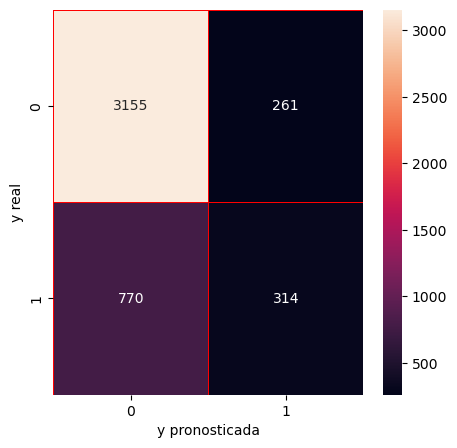

              precision    recall  f1-score   support

       False       0.80      0.92      0.86      3416
        True       0.55      0.29      0.38      1084

    accuracy                           0.77      4500
   macro avg       0.67      0.61      0.62      4500
weighted avg       0.74      0.77      0.74      4500



In [31]:
SVM_Resumido(Opcion_Kernel[0], x_train, x_test, y_train, y_test, x)

### Analisis:
Tiene una precisión para predecir falsos verdaderos (quien se quedarían) del 80% pero una precisión para saber quién se quedará del 29% con solo estas estadísticas este modelo queda descartado, dado que si tomamos la precisión global es del 77% lo cual en un modelo realista está cerca del mínimo de precisión de un modelo (70%) para ser ACEPTABLE (No Bueno, solo aceptable).


### SVM Polynomial

[[3416    0]
 [1084    0]]


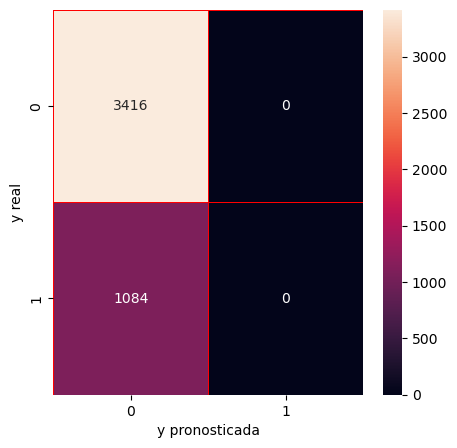

              precision    recall  f1-score   support

       False       0.76      1.00      0.86      3416
        True       0.00      0.00      0.00      1084

    accuracy                           0.76      4500
   macro avg       0.38      0.50      0.43      4500
weighted avg       0.58      0.76      0.66      4500



D:\Programas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Programas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Programas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
SVM_Resumido(Opcion_Kernel[1], x_train, x_test, y_train, y_test, x)

### Analisis: 
Completamente descartado, aunque los valores sean "altos" en calcular quienes se quedaron (Falso, Falso), en realidad lo único que hizo fue colocar todos en falsos (que se quedarían) y ya, no predijo, ni nada, por lo cual este modelo se descartó completamente para este caso.
Se dejaron las advertencias para poder analizar que posibles resultados podrían salir, incluyendo errores en mi código.

### SVM Radial Basis function (RBF)

[[3416    0]
 [1043   41]]


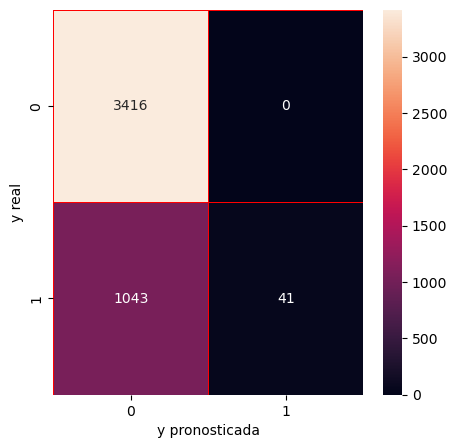

              precision    recall  f1-score   support

       False       0.77      1.00      0.87      3416
        True       1.00      0.04      0.07      1084

    accuracy                           0.77      4500
   macro avg       0.88      0.52      0.47      4500
weighted avg       0.82      0.77      0.68      4500



In [39]:
SVM_Resumido(Opcion_Kernel[2], x_train, x_test, y_train, y_test, x)

### Analisis:
El modelo presento una predicción muy escaza, presentando una predicción correcta de cuantos se retirarían de alrededor del 4% y para predecir cuantos se quedarían sería de alrededor del 77% correctos, con esto dicho el modelo sigue siendo muy deficiente, por lo cual se tendrá que buscar otro modelo.

### SVM Sigmoid

[[2811  605]
 [ 752  332]]


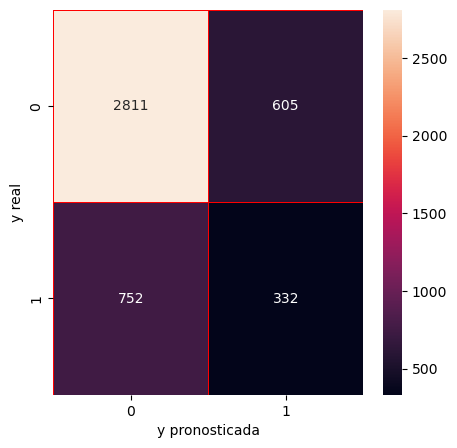

              precision    recall  f1-score   support

       False       0.79      0.82      0.81      3416
        True       0.35      0.31      0.33      1084

    accuracy                           0.70      4500
   macro avg       0.57      0.56      0.57      4500
weighted avg       0.68      0.70      0.69      4500



In [43]:
SVM_Resumido(Opcion_Kernel[3], x_train, x_test, y_train, y_test, x)

### Analisis:
El modelo presenta una precisión para su predicción de quienes se quedarían del 82%, pero para quienes se retirarían del 31%, mostrando una precisión global del 70% lo cual a duras penas sería un modelo aceptable, pero debido a que es un modelo utilizado para saber quién se retiraría y se quedaría aun cuando tiene una precisión mayor para saber quién se retirara que el modelo lineal, en este caso sus fallos serían mayores, lo cual lo dejaría como la segunda opción.

### ¿Qué resultado pronosticaría para un empleado con los siguientes indicadores?
Se usara una SVM Lineal

In [158]:
ejemplo = x.iloc[0].copy()
ejemplo

satisfaction_level        0.38
last_evaluation           0.53
number_project               2
average_montly_hours       157
time_spend_company           3
Work_accident            False
promotion_last_5years    False
sales_IT                 False
sales_RandD              False
sales_accounting         False
sales_hr                 False
sales_management         False
sales_marketing          False
sales_product_mng        False
sales_sales               True
sales_support            False
sales_technical          False
salary_high              False
salary_low                True
salary_medium            False
Name: 0, dtype: object

In [153]:
ejemplo["satisfaction_level"] = 0.5
ejemplo["last_evaluation"] = 0.75
ejemplo["number_project"] = 4
ejemplo["average_montly_hours"] = 200
ejemplo["time_spend_company"] = 4
ejemplo["Work_accident"] = False
ejemplo["promotion_last_5years"] = False
ejemplo["sales_IT"] = False
ejemplo["sales_RandD"] = False
ejemplo["sales_accounting"] = False
ejemplo["sales_hr"] = False
ejemplo["sales_management"] = False
ejemplo["sales_marketing"] = False
ejemplo["sales_product_mng"] = False
ejemplo["sales_sales"] = True # Department Sales
ejemplo["sales_support"] = False
ejemplo["sales_technical"] = False
ejemplo["salary_high"] = False
ejemplo["salary_low"] = False
ejemplo["salary_medium"] = True
ejemplo

satisfaction_level         0.5
last_evaluation           0.75
number_project               4
average_montly_hours       200
time_spend_company           4
Work_accident            False
promotion_last_5years    False
sales_IT                 False
sales_RandD              False
sales_accounting         False
sales_hr                 False
sales_management         False
sales_marketing          False
sales_product_mng        False
sales_sales               True
sales_support            False
sales_technical          False
salary_high              False
salary_low               False
salary_medium             True
Name: 0, dtype: object

In [176]:
from sklearn import svm
from sklearn.metrics import confusion_matrix

#Seleccion y entrenamiento del Kernerl
clf = svm.SVC(kernel= Opcion_Kernel[0])
clf.fit(x_train, y_train)
    
#Prediccion con valores de prueba de X
yhat = clf.predict(x_test)

#Matriz de confusión
y_pred = clf.predict(pd.DataFrame(ejemplo).transpose())

print("Valores insertados", ejemplo)
if y_pred == False:
    print("La persona se quedara")
else:
    print("La persona se retirara")

Valores insertados satisfaction_level        0.38
last_evaluation           0.53
number_project               2
average_montly_hours       157
time_spend_company           3
Work_accident            False
promotion_last_5years    False
sales_IT                 False
sales_RandD              False
sales_accounting         False
sales_hr                 False
sales_management         False
sales_marketing          False
sales_product_mng        False
sales_sales               True
sales_support            False
sales_technical          False
salary_high              False
salary_low                True
salary_medium            False
Name: 0, dtype: object
La persona se quedara


## Desición
De acuerdo con los análisis y las predicciones hechas los modelos que se PODRÍAN utilizar serian:
1. Lineal
2. Polinomial

Se descartó la Radial Basis function debido a que a duras penas predecía correctamente quienes se retirarían y la Polynomial directamente no se considera dado que predice que TODOS los trabajadores se quedarían.

# Comentarios generales de mi propio codigo

El código esta resumido por las funciones, el problema es que el tiempo de ejecución incrementa debido a que importa las librerías y redefine cada variable en cada ejecución sin hablar de las subsfunciones, pero para fines de estudio es útil dado que explica que elementos ocupa cada paso y permite analizar el proceso de manera resumida.